In [1]:

import os
import re
import pandas as pd
import numpy as np
import optuna
import torch
import random
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from black import format_str, FileMode
from tqdm import tqdm
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings("ignore")

# we have to make a diagram where the code input and it show outputs by passing through different models



In [2]:
from huggingface_hub import notebook_login
notebook_login()

In [3]:
# for code run locally
# login to hugging face

splits = {
    'train': 'task_a/task_a_training_set_1.parquet', 
    'validation': 'task_a/task_a_validation_set.parquet', 
    'test': 'task_a/task_a_test_set_sample.parquet'
}

base_path = "hf://datasets/DaniilOr/SemEval-2026-Task13/"

# Load each split into Pandas
train_data = pd.read_parquet(base_path + splits["train"])
val_data = pd.read_parquet(base_path + splits["validation"])
test_data = pd.read_parquet(base_path + splits["test"])

In [ ]:
# # run code on kaggle

# train_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_training_set_1.parquet"
# val_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_validation_set.parquet"
# test_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_test_set_sample.parquet"


# # load train,test & validation data
# train_data = pd.read_parquet(train_path)
# val_data = pd.read_parquet(val_path)
# test_data = pd.read_parquet(test_path)

In [8]:
train_data.head()

,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python
3,T = int(input())\nfor t in range(T):\n\tcolor ...,human,0,Python
4,for i in range(int(input())):\n\tinput()\n\ta ...,human,0,Python


In [4]:


# Basic cleaning
# ====================================================
#  Extra features 
# ====================================================

camel_case_pattern = r'\b[a-z]+(?:[A-Z][a-z0-9]+)+\b'
snake_case_pattern = r'\b[a-z]+(?:_[a-z0-9]+)+\b'

def count_camel(text):
    return len(re.findall(camel_case_pattern, text))

def count_snake(text):
    return len(re.findall(snake_case_pattern, text))


# training dataset

train_data['code'] = train_data['code'].astype(str)

train_data['camel_count'] = train_data['code'].apply(count_camel)
train_data['snake_count'] = train_data['code'].apply(count_snake)

train_data['total_idents'] = train_data['camel_count'] + train_data['snake_count']
train_data['camel_ratio'] = train_data['camel_count'] / (train_data['total_idents'] + 1e-5)
train_data['snake_ratio'] = train_data['snake_count'] / (train_data['total_idents'] + 1e-5)


# Code Features Extraction 
train_data["code_length"] = train_data["code"].str.len()
train_data['num_comments'] = train_data['code'].str.count("#|//")
train_data['num_tabs'] = train_data['code'].str.count("\t")
train_data['num_spaces'] = train_data['code'].str.count("    ")

train_data["num_lines"] = train_data["code"].apply(lambda x: x.count("\n") + 1)
train_data["num_defs"] = train_data["code"].str.count(r"\bdef\b")
train_data["num_for"] = train_data["code"].str.count(r"\bfor\b")
train_data["num_if"] = train_data["code"].str.count(r"\bif\b")
train_data["num_import"] = train_data["code"].str.count(r"\bimport\b")


In [5]:
# test dataset 

test_data['code'] = test_data['code'].astype(str)

test_data['camel_count'] = test_data['code'].apply(count_camel)
test_data['snake_count'] = test_data['code'].apply(count_snake)
test_data['total_idents'] = test_data['camel_count'] + test_data['snake_count']
test_data['camel_ratio'] = test_data['camel_count'] / (test_data['total_idents'] + 1e-5)
test_data['snake_ratio'] = test_data['snake_count'] / (test_data['total_idents'] + 1e-5)

# Code Features Extraction 
test_data["code_length"] = test_data["code"].str.len()
test_data['num_comments'] = test_data['code'].str.count("#|//")
test_data['num_tabs'] = test_data['code'].str.count("\t")
test_data['num_spaces'] = test_data['code'].str.count("    ")

test_data["num_lines"] = test_data["code"].apply(lambda x: x.count("\n") + 1)
test_data["num_defs"] = test_data["code"].str.count(r"\bdef\b")
test_data["num_for"] = test_data["code"].str.count(r"\bfor\b")
test_data["num_if"] = test_data["code"].str.count(r"\bif\b")
test_data["num_import"] = test_data["code"].str.count(r"\bimport\b")

In [6]:
# ====================================================
# Train-test split
# ====================================================

X_train_text, y_train = train_data["code"], train_data["label"]
X_test_text, y_test = test_data["code"], test_data["label"]
X_val_text, y_val = val_data["code"], val_data["label"]


## Hyperparameter Tuning Optuna Objective Function

In [ ]:

# ------------------------------------------------------
# Optuna Objective Function
# ------------------------------------------------------
def objective(trial):

    # TF-IDF hyperparameters
    max_features = trial.suggest_categorical("max_features", [10000, 20000, 30000])
    ngram_range = trial.suggest_categorical("ngram_range", [ ])
    min_df = trial.suggest_float("min_df", 1e-5, 0.01, log=True)

    # Logistic Regression hyperparameters
    C = trial.suggest_float("C", 1e-3, 10, log=True)
    solver = trial.suggest_categorical("solver", ["liblinear", "lbfgs"])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    # Pipeline definition
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            strip_accents="unicode",
            analyzer="word",
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df
        )),
        ("clf", LogisticRegression(
            C=C,
            solver=solver,
            class_weight=class_weight,
            max_iter=5000,
            n_jobs=-1
        ))
    ])

    # Fit model
    pipe.fit(X_train_text, y_train)

    # Predict & compute F1 score
    preds = pipe.predict(X_test_text)
    score = f1_score(y_test, preds, average="macro")

    return score


# ------------------------------------------------------
# Run Optuna Study
# ------------------------------------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  # increase n_trials for better results

# Best hyperparameters
print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

# best_params = {'max_features': 30000, 'ngram_range': (1, 1), 'min_df': 0.0015430189491796615, 'C': 8.853443301355558, 'solver': 'liblinear', 'class_weight': 'balanced'}

In [7]:
best_params = {'max_features': 30000, 'ngram_range': (1, 1), 'min_df': 0.0015430189491796615, 'C': 8.853443301355558, 'solver': 'liblinear', 'class_weight': 'balanced'}

In [8]:
tfidf = TfidfVectorizer(
        strip_accents="unicode",
        analyzer="word",
        max_features=best_params["max_features"],
        ngram_range=best_params["ngram_range"],
        min_df=best_params["min_df"]
    )


X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)
# validation data
X_val_tfidf  = tfidf.transform(X_val_text)

In [9]:

# ====================================================
#  Metadata features
# ====================================================

meta_features = [
    # 'language',
    'camel_count',
    'snake_count',
    'camel_ratio',
    'snake_ratio',
    "code_length",
    "num_comments",
    "num_tabs",
    "num_spaces",
    "num_lines",
    "num_defs",
    "num_for",
    "num_if",
    "num_import"   
]

X_train_meta = train_data[meta_features].values
X_test_meta = test_data[meta_features].values


# Combine sparse and dense features
from scipy.sparse import hstack

X_train_meta_tfidf_data = hstack([X_train_tfidf, X_train_meta])
X_test_meta_tfidf_data  = hstack([X_test_tfidf, X_test_meta])

In [10]:

# ====================================================
#  Define Models
# ====================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Multinomial NB": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

# Optional (if installed)
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        eval_metric='logloss',
        tree_method='hist'
    )
except:
    pass

try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier()
except:
    pass

# ====================================================
# Train and Evaluate All Models
# ====================================================

results = []

for name, model in models.items():
    print("="*60)
    print(f"Training {name}...")
    
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(classification_report(y_test, pred))

    results.append([name, acc, f1])

# Results summary
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
results_df = results_df.sort_values("F1 Score", ascending=False)

print("\n\n==== FINAL RESULTS ====")
print(results_df)



Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.90      0.32      0.48       777
           1       0.27      0.87      0.41       223

    accuracy                           0.45      1000
   macro avg       0.58      0.60      0.44      1000
weighted avg       0.76      0.45      0.46      1000

Training Multinomial NB...
              precision    recall  f1-score   support

           0       0.86      0.20      0.32       777
           1       0.24      0.89      0.38       223

    accuracy                           0.35      1000
   macro avg       0.55      0.54      0.35      1000
weighted avg       0.72      0.35      0.33      1000

Training Linear SVM...
              precision    recall  f1-score   support

           0       0.90      0.36      0.51       777
           1       0.28      0.86      0.42       223

    accuracy                           0.47      1000
   macro avg       0.59      0.61      0.46   

<!-- Train The Model on Combine  Metadata features and tfidf vectors --> 

In [12]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Multinomial NB": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    # "Decision Tree": DecisionTreeClassifier(),
    # "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

# Optional (if installed)
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        eval_metric='logloss',
        tree_method='hist'
    )
except:
    pass



results = []

for name, model in models.items():
    print("="*60)
    print(f"Training {name}...")
    
    model.fit(X_train_meta_tfidf_data, y_train)
    pred = model.predict(X_test_meta_tfidf_data)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(classification_report(y_test, pred))

    results.append([name, acc, f1])

# Results summary
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
results_df = results_df.sort_values("F1 Score", ascending=False)

print("\n\n==== FINAL RESULTS ====")
print(results_df)



Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.86      0.33      0.48       777
           1       0.26      0.81      0.39       223

    accuracy                           0.44      1000
   macro avg       0.56      0.57      0.43      1000
weighted avg       0.72      0.44      0.46      1000

Training Multinomial NB...
              precision    recall  f1-score   support

           0       0.93      0.27      0.42       777
           1       0.27      0.93      0.42       223

    accuracy                           0.42      1000
   macro avg       0.60      0.60      0.42      1000
weighted avg       0.78      0.42      0.42      1000

Training Linear SVM...
              precision    recall  f1-score   support

           0       0.86      0.32      0.47       777
           1       0.26      0.82      0.39       223

    accuracy                           0.43      1000
   macro avg       0.56      0.57      0.43   

##  XGBClassifier

In [24]:
#
def dedupe(df):
    return df.drop_duplicates(subset=["code"]).reset_index(drop=True)
train = dedupe(train_data)
val = dedupe(val_data)
test = dedupe(test_data)

print(len(train), len(val), len(test))

500000 100000 1000


In [27]:
train.head(2)

,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python


In [30]:
 
def normalize(code):
    return code.replace("\t", " ").replace("\r", "").strip()

train["code"] = train["code"].apply(normalize)
val["code"] = val["code"].apply(normalize)
test["code"] = test["code"].apply(normalize)


tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,6),
    max_features=20000,
    min_df=2  
)

tfidf_train = tfidf.fit_transform(train["code"])
tfidf_val   = tfidf.transform(val["code"])
tfidf_test  = tfidf.transform(test["code"])

print("TF-IDF shape:", tfidf_train.shape)

TF-IDF shape: (500000, 20000)


In [31]:
X_train = tfidf_train
X_val   = tfidf_val
X_test  = tfidf_test

y_train = train["label"]
y_val   = val["label"]
y_test  = test["label"]

print(X_train.shape)


(500000, 20000)


In [32]:
from xgboost import XGBClassifier
clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.5,
    max_bin=128,
    tree_method="hist",
    eval_metric="logloss",
    early_stopping_rounds=50,
    verbosity=1
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)




[0]	validation_0-logloss:0.67553
[1]	validation_0-logloss:0.65927
[2]	validation_0-logloss:0.64439
[3]	validation_0-logloss:0.63035
[4]	validation_0-logloss:0.61698
[5]	validation_0-logloss:0.60441
[6]	validation_0-logloss:0.59165
[7]	validation_0-logloss:0.58011
[8]	validation_0-logloss:0.56888
[9]	validation_0-logloss:0.55799
[10]	validation_0-logloss:0.54706
[11]	validation_0-logloss:0.53713
[12]	validation_0-logloss:0.52765
[13]	validation_0-logloss:0.51908
[14]	validation_0-logloss:0.50976
[15]	validation_0-logloss:0.50169
[16]	validation_0-logloss:0.49355
[17]	validation_0-logloss:0.48585
[18]	validation_0-logloss:0.47802
[19]	validation_0-logloss:0.47093
[20]	validation_0-logloss:0.46410
[21]	validation_0-logloss:0.45683
[22]	validation_0-logloss:0.45066
[23]	validation_0-logloss:0.44473
[24]	validation_0-logloss:0.43886
[25]	validation_0-logloss:0.43266
[26]	validation_0-logloss:0.42714
[27]	validation_0-logloss:0.42142
[28]	validation_0-logloss:0.41612
[29]	validation_0-loglos

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'logloss'


In [36]:
# Evaluation of the model on the test dataset
pred = clf.predict(X_val)
print(classification_report(y_val, pred, digits=4))

              precision    recall  f1-score   support

           0     0.9199    0.9515    0.9354     47695
           1     0.9544    0.9244    0.9391     52305

    accuracy                         0.9373    100000
   macro avg     0.9371    0.9380    0.9373    100000
weighted avg     0.9379    0.9373    0.9374    100000



In [ ]:

# ====================================================
#  Define Models
# ====================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Multinomial NB": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    # "Decision Tree": DecisionTreeClassifier(), (takes too long to train)
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}


try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier()
except:
    pass

# ====================================================
# Train and Evaluate All Models
# ====================================================

results = []

for name, model in models.items():
    print("="*60)
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(classification_report(y_test, pred))
    
    # Evaluation of the model on the validation dataset 
    print("\nValidation Set Evaluation:")
    pred = model.predict(X_val)
    print(classification_report(y_val, pred, digits=4))
    

    results.append([name, acc, f1])

# Results summary
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
results_df = results_df.sort_values("F1 Score", ascending=False)

print("\n\n==== FINAL RESULTS ====")
print(results_df)



Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.91      0.15      0.26       777
           1       0.24      0.95      0.39       223

    accuracy                           0.33      1000
   macro avg       0.57      0.55      0.32      1000
weighted avg       0.76      0.33      0.29      1000


Validation Set Evaluation:
              precision    recall  f1-score   support

           0     0.9305    0.9532    0.9417     47695
           1     0.9564    0.9351    0.9456     52305

    accuracy                         0.9437    100000
   macro avg     0.9434    0.9442    0.9437    100000
weighted avg     0.9440    0.9437    0.9438    100000

Training Multinomial NB...
              precision    recall  f1-score   support

           0       0.87      0.08      0.15       777
           1       0.23      0.96      0.37       223

    accuracy                           0.28      1000
   macro avg       0.55      0.52      0.

### Best Model From Experiments Is SVM with TF-IDF

In [9]:
best_params

{'max_features': 30000,
 'ngram_range': (1, 1),
 'min_df': 0.0015430189491796615,
 'C': 8.853443301355558,
 'solver': 'liblinear',
 'class_weight': 'balanced'}

In [11]:
logisticRegressionclf =  LogisticRegression(
            C=best_params['C'],
            solver=best_params['solver'],
            class_weight=best_params['class_weight'],
            max_iter=5000,
            n_jobs=-1
        )

print("="*60)    
logisticRegressionclf.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,8.853443301355558
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


In [16]:
pred = logisticRegressionclf.predict(X_test_tfidf)

acc = accuracy_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(classification_report(y_test, pred))
print("="*60)
print(f"Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

              precision    recall  f1-score   support

           0       0.89      0.35      0.50       777
           1       0.27      0.85      0.41       223

    accuracy                           0.46      1000
   macro avg       0.58      0.60      0.46      1000
weighted avg       0.75      0.46      0.48      1000

Accuracy: 0.4620, F1 Score: 0.4127


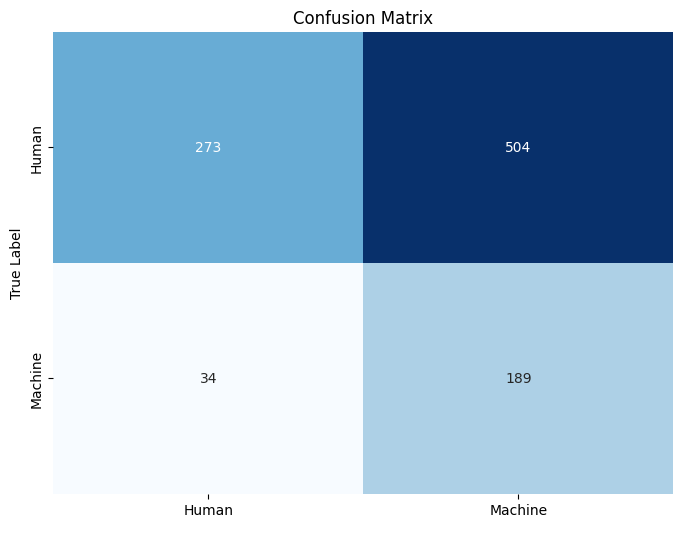

In [23]:
#  i want to show it using giraphical representation  give name to lable  "human": 0, "machine": 1
import matplotlib.pyplot as plt 
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Human', 'Machine'],
            yticklabels=['Human', 'Machine'])   
plt.xlabel(' ')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
# Save figure as PDF
plt.savefig("plots/confusion_matrix_svm_human_vs_machine.pdf", bbox_inches="tight")
plt.show()

#  save this graphical representation as png file 


In [ ]:
#  i want to elvaluate only machine generated code  which is label 1
machine_indices = y_test[y_test == 1].index
X_test_machine = X_test_tfidf[machine_indices]